## Multiple Inheritance in Python

When a class inherits from more than one base class, it is called multiple inheritance. The derived class inherits all features of its base classes.
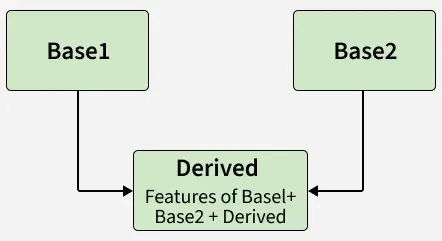

In [ ]:
# Syntax:
class Base1:
     # Body of the class
        pass

class Base2:
    # Body of the class
        pass

class Derived(Base1, Base2):
         # Body of the class
         pass 

### The Diamond Problem
Diamond Problem occurs when two classes inherit from a common superclass, and another class inherits from both. If a method is overridden in the intermediate classes, ambiguity arises about which method the derived class should use.



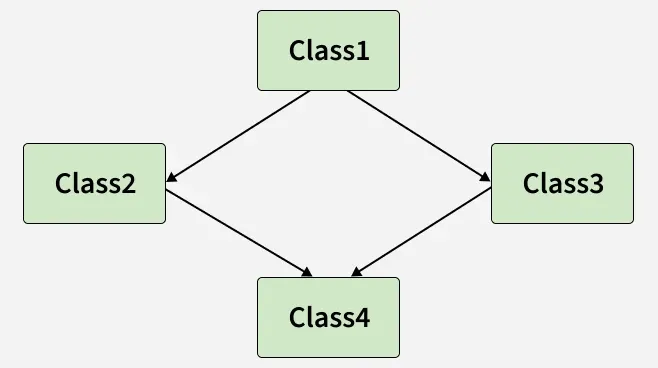

Class1 is the base, Class2 and Class3 inherit from it, Class4 inherits from both.

Calling a method overridden in Class2 and Class3 creates ambiguity.

Python uses MRO to resolve it and ensure a consistent call sequence.

Python have a built-in solution to the Diamond Problem, and it's handled through the Method Resolution Order (MRO) using the C3 linearization algorithm.

### Method Resolution Order
Method Resolution Order (MRO) in Python determines the order in which base classes are searched when looking for an attribute in multiple inheritance. It follows a linearization rule: the current class is checked first, then parent classes are searched from left to right, each class only once. You can view it using:

Class.mro()-> returns a list
Class.__mro__ -> returns a tuple
The below code demonstrates the use of super() with multiple inheritance: calling obj.m() executes the m methods following the Method Resolution Order (MRO), ensuring each parent method is called once. The mro() and __mro__ outputs show the search order: Class4 -> Class2 -> Class3 -> Class1 -> object.






In [1]:
class Class1:
    def m(self):
        print("In Class1")

class Class2(Class1):
    def m(self):
        print("In Class2")
        super().m()

class Class3(Class1):
    def m(self):
        print("In Class3")
        super().m()

class Class4(Class2, Class3):
    def m(self):
        print("In Class4")   
        super().m()
     
print(Class4.mro())         
print(Class4.__mro__)

[<class '__main__.Class4'>, <class '__main__.Class2'>, <class '__main__.Class3'>, <class '__main__.Class1'>, <class 'object'>]
(<class '__main__.Class4'>, <class '__main__.Class2'>, <class '__main__.Class3'>, <class '__main__.Class1'>, <class 'object'>)


#### Example 1: When the method is overridden in both classes

The code demonstrates multiple inheritance where Class4 inherits from Class2 and Class3; calling obj.m() executes Class2’s method because, according to Python’s MRO, Class2 is checked before Class3.

In [4]:
class Class1:
    def m(self):
        print("In Class1") 
      
class Class2(Class1):
    def m(self):
        print("In Class2")

class Class3(Class1):
    def m(self):
        print("In Class3")  
       
class Class4(Class2, Class3):
    pass   
    
obj = Class4()
obj.m()

In Class2


##### Example 2: When the Method overridden in one class only
The code shows multiple inheritance where Class4 inherits from Class2 and Class3; calling obj.m() executes Class3’s method due to Python’s method resolution order (MRO).

In [5]:
class Class1:
    def m(self):
        print("In Class1")

class Class2(Class1):
    pass

class Class3(Class1):
    def m(self):
        print("In Class3")

class Class4(Class2, Class3):
    pass

obj = Class4()
obj.m()

In Class3


#### Example 3: All classes define the same method
The code demonstrates multiple inheritance, showing that Class4 overrides the m method, but methods from parent classes (Class2, Class3, Class1) can still be called explicitly using the class name.

In [10]:
class Class1:
    def m(self):
        print("In Class1")

class Class2(Class1):
    def m(self):
        print("In Class2")

class Class3(Class1):
    def m(self):
        print("In Class3")

class Class4(Class2, Class3):
    def m(self):
        print("In Class4")

obj = Class4()
obj.m()
Class2.m(obj)
Class3.m(obj)
Class1.m(obj)

In Class4
In Class2
In Class3
In Class1


#### Example 4: Calling methods of parent classes from child class
The code demonstrates multiple inheritance and explicitly calls parent class methods, showing how Class1.m() is invoked multiple times through Class2 and Class3.

In [11]:
class Class1:
    def m(self):
        print("In Class1")

class Class2(Class1):
    def m(self):
        print("In Class2")
        Class1.m(self)

class Class3(Class1):
    def m(self):
        print("In Class3")
        Class1.m(self)

class Class4(Class2, Class3):
    def m(self):
        print("In Class4")
        Class2.m(self)
        Class3.m(self)

obj = Class4()
obj.m()

In Class4
In Class2
In Class1
In Class3
In Class1


## Super Function 
Super Function in Python is used to call a method from a parent (base) class, especially in multiple inheritance. It helps avoid explicitly naming the parent class, ensures proper method resolution following the MRO, and prevents duplicate calls of the same method.






In [14]:
class Class1:
    def m(self):
        print("In Class1")

class Class2(Class1):
    def m(self):
        print("In Class2")
        super().m()

class Class3(Class1):
    def m(self):
        print("In Class3")
        super().m()

class Class4(Class2, Class3):
    def m(self):
        print("In Class4")   
        super().m()

# mro order for class4
print(Class4.mro()   )
obj = Class4()
obj.m()


[<class '__main__.Class4'>, <class '__main__.Class2'>, <class '__main__.Class3'>, <class '__main__.Class1'>, <class 'object'>]
In Class4
In Class2
In Class3
In Class1


Explanation:

Class4 inherits from Class2 and Class3, which both inherit from Class1, forming a diamond.

Each class defines its own m() method.

super() calls the next method in the Method Resolution Order (MRO).

MRO for Class4 is Class4 -> Class2 -> Class3 -> Class1.

Calling obj.m() executes the methods in MRO order.